# Exploratory Data Analysis & Feature Construction

*Explores 1M+ transactions from a UK-based online giftware retailer (2009-2011) to uncover the behavioral patterns that drive repeat purchasing, and to build the feature set that powers the rest of this pipeline.*

---

**Business Question:** What behavioral patterns distinguish customers who will buy again from those who won't, and can we engineer features that capture this signal?

- **Context:** To maximize marketing ROI, e-commerce businesses must shift from blanket promotions to targeted retention strategies. This requires understanding historical purchasing behavior and isolating the specific customer signals that indicate future loyalty.

**Approach:** Starting from raw transactional data, we clean ~1M rows, construct a temporal calibration/holdout split (mimicking a real production forecast), and engineer 13 customer-level features grounded in RFM analysis. The EDA then investigates revenue concentration, purchase frequency, geographic skew, and feature-target correlations to validate that the features carry predictive signal before any model is trained.

**Key Findings:**
- **Revenue is highly concentrated:** Top 20% of customers account for **75%** of total calibration spend, directly motivating a tier-based segmentation strategy
- **31% are one-time buyers**, yet they still purchase in the holdout window. Worth keeping in the model.
- **Q4 seasonality:** November is consistently the highest-revenue month of the year
- **RFM features carry strong signal:** `recency` (r = −0.45) is the single strongest predictor of future purchase, followed by `is_one_time_buyer` (r = −0.35), `unique_products` (r = +0.30), and `frequency` (r = +0.26)
- **91.6% UK-based:** The model is predominantly UK-calibrated

**Inputs / Outputs:**
- Input: [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) (raw Excel, ~1M transactions)
- Output: `data/processed/clv_data.csv` (4,918 customers × 17 columns: 13 features + holdout labels)

*This notebook produces the modeling dataset used in `02_purchase_propensity_model.ipynb` (Stage 1).*

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

## Data Dictionary

| Column | Description | Type | Notes |
|---------------|-------------|-----------|------|
| Invoice | Invoice number | Nominal | A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter **'C'**, it indicates a cancellation. |
| StockCode | Product (item) code | Nominal | A 5-digit integral number uniquely assigned to each distinct product. |
| Description | Product (item) name | Nominal | Name of the product. |
| Quantity | Quantity per transaction | Numeric | The quantities of each product (item) in each transaction. |
| InvoiceDate | Invoice date and time | Numeric (Datetime) | The day and time when a transaction was generated. |
| Price | Unit price | Numeric | Product price per unit in sterling (£). |
| Customer ID | Customer number | Nominal | A 5-digit integral number uniquely assigned to each customer. |
| Country | Country name | Nominal | The country where the customer resides. |

## 1. Load Data

In [2]:
# Load data from local file (originally sourced from UCI repository)
# Source: https://archive.ics.uci.edu/dataset/502/online+retail+ii
sheet1 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name="Year 2009-2010")
sheet2 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name="Year 2010-2011")
df_raw = pd.concat([sheet1, sheet2], ignore_index=True)
print(f" Shape: {df_raw.shape}")
df_raw.head()

 Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [4]:
# Check missing values per column
print(df_raw.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [5]:
# Check number of unique values per column
df_raw.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

In [6]:
df_raw.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


## 2. Data Cleaning

In [7]:
# --- Clean ---
df = df_raw.copy()
df['Invoice'] = df['Invoice'].astype(str).str.strip()

# Identify cancellations (invoices starting with 'C') before filtering them out, as we need this info for the cancellation_rate feature
df['is_cancellation'] = df['Invoice'].str.startswith('C')

# Save cancellation info for calibration-period-only computation in cell 13 (prevents holdout data leakage)
_cancel_ref = df[df['Customer ID'].notna()][['Invoice', 'Customer ID', 'InvoiceDate', 'is_cancellation']].copy()
_cancel_ref['Customer ID'] = _cancel_ref['Customer ID'].astype(int)

# Only keep rows with valid Customer ID, non-cancellations, and positive Quantity and Price
df = df[df['Customer ID'].notna()].copy()
df['Customer ID'] = df['Customer ID'].astype(int)
df = df[~df['is_cancellation']].copy()
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()

# Remove non-product codes and short alpha codes
# These were identified by manual inspection of short alpha StockCodes and their descriptions:
#   'POST' = postage, 'DOT' = dotcom postage, 'M' = manual adjustment,
#   'BANK CHARGES' = bank fees, 'CRUK'/'AMAZONFEE' = platform fees,
#   'gift_0001_*' = gift card top-ups (not product purchases)
non_product_codes = {'POST', 'DOT', 'M', 'BANK CHARGES', 'PADS', 'S', 'CRUK', 'AMAZONFEE',
                     'D', 'C2', 'DCGS', 'DCGSSBOY', 'DCGSSGIRL', 'SP1002',
                     'gift_0001_10', 'gift_0001_20', 'gift_0001_30', 'gift_0001_40', 'gift_0001_50'}
is_alpha_short = df['StockCode'].astype(str).str.match(r'^[A-Za-z]{1,5}$')
is_known_non_product = df['StockCode'].astype(str).str.upper().isin({c.upper() for c in non_product_codes})
df = df[~(is_alpha_short | is_known_non_product)].copy()
df = df.drop_duplicates().copy()
df['line_total'] = df['Quantity'] * df['Price']
df = df.drop(columns=['is_cancellation'])
rows_before = len(df_raw)

print(f"Raw rows:         {rows_before:,}")
print(f"Cleaned rows:     {len(df):,} ({len(df)/rows_before:.1%} retained)")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Date range:       {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

Raw rows:         1,067,371
Cleaned rows:     776,622 (72.8% retained)
Unique customers: 5,861
Date range:       2009-12-01 to 2011-12-09


**Note on extreme values:** 

- The raw data contains transactions with quantities up to 80,995 and unit prices up to £38,970. These are B2B/wholesale orders rather than individual consumer purchases. 
- After cleaning, a small number of customers (e.g., Customer 12346 with £77K calibration spend across 12 orders) remain as high-spend outliers. 
- We retain these customers because: (1) they represent real business value for segmentation purposes, and (2) tree-based models (XGBoost) are robust to outlier magnitude since they split on rank order, not absolute values, and (3) removing high-spend customers would bias the CLV segmentation in `03_customer_lifetime_value_segmentation.ipynb`, since these are the exact customers that tier-based marketing strategies are designed to retain.

## 3. Temporal Train / Validation Split

To prevent data leakage, customer features are constructed using only historical transactions (calibration period), and model performance is evaluated on future purchasing behavior (holdout period).

| Period | Date Range | Purpose |
|---|---|---|
| **Calibration** | Start → 2011-06-09 | Compute customer features |
| **Holdout** | 2011-06-09 → 2011-12-09 | Measure repeat purchase and future revenue |

The holdout window acts as a **future observation period**, allowing us to measure both:

- **Purchase propensity** (does the customer return?)
- **Future revenue** (how much they spend)

In [8]:
# --- Temporal split ---
calibration_end = pd.Timestamp('2011-06-09')
cutoff_date     = pd.Timestamp('2011-12-09')

calibration = df[df['InvoiceDate'] < calibration_end].copy()
holdout     = df[(df['InvoiceDate'] >= calibration_end) & (df['InvoiceDate'] < cutoff_date)].copy()

print(f"  Transactions in calibration period: {len(calibration):,} ({len(calibration)/len(df):.1%})")
print(f"  Transactions in holdout period:     {len(holdout):,} ({len(holdout)/len(df):.1%})")

  Transactions in calibration period: 536,391 (69.1%)
  Transactions in holdout period:     239,626 (30.9%)


## 4. Feature Engineering

Using the calibration period, we build customer-level features based on **RFM patterns** and additional behavioral signals, including order value, basket size, product diversity, inter-purchase variability, cancellation behavior, and country.

These features summarize each customer's historical purchasing behavior prior to the prediction window.

In [9]:
# --- Order-level aggregation ---
cal_orders = calibration.groupby(['Customer ID', 'Invoice']).agg(
    order_date=('InvoiceDate', 'min'),
    order_revenue=('line_total', 'sum'),
    n_items=('StockCode', 'nunique'),
).reset_index()

# --- Customer-level RFM features ---
customer_agg = cal_orders.groupby('Customer ID').agg(
    first_order_date=('order_date', 'min'),
    last_order_date=('order_date', 'max'),
    total_orders=('Invoice', 'nunique'),
    total_spend=('order_revenue', 'sum'),
    avg_order_value=('order_revenue', 'mean'),
    avg_basket_size=('n_items', 'mean'),
).reset_index()

customer_agg['frequency'] = customer_agg['total_orders'] - 1
customer_agg['recency']   = (calibration_end - customer_agg['last_order_date']).dt.days
customer_agg['T']         = (calibration_end - customer_agg['first_order_date']).dt.days

def compute_monetary_value(group):
    s = group.sort_values('order_date')
    return s.iloc[1:]['order_revenue'].mean() if len(s) > 1 else s['order_revenue'].mean()

mv = cal_orders.groupby('Customer ID').apply(compute_monetary_value)
mv.name = 'monetary_value'
customer_agg = customer_agg.merge(mv, on='Customer ID', how='left')

unique_products = calibration.groupby('Customer ID')['StockCode'].nunique().rename('unique_products').reset_index()
customer_agg = customer_agg.merge(unique_products, on='Customer ID', how='left')

def compute_interpurchase_std(group):
    dates = group.sort_values('order_date')['order_date']
    if len(dates) < 2: return np.nan
    intervals = dates.diff().dropna().dt.days
    return 0.0 if len(intervals) < 2 else intervals.std()

pr = cal_orders.groupby('Customer ID').apply(compute_interpurchase_std).rename('interpurchase_std').reset_index()
customer_agg = customer_agg.merge(pr, on='Customer ID', how='left')

# One-time buyer flag (explicit binary feature), replaces the 999 sentinel value approach.
# This lets the model learn one-time buyer behavior directly, while interpurchase_std
# remains a clean continuous feature (0 for customers with insufficient purchase history).
customer_agg['is_one_time_buyer'] = (customer_agg['frequency'] == 0).astype(int)
customer_agg['interpurchase_std'] = customer_agg['interpurchase_std'].fillna(0)

# Cancellation rate, calibration period only (prevents holdout data leakage)
_cal_cancel = _cancel_ref[_cancel_ref['InvoiceDate'] < calibration_end]
cancellation_counts = (_cal_cancel[_cal_cancel['is_cancellation']].groupby('Customer ID')['Invoice']
                       .nunique().rename('cancellation_orders'))
total_orders_with_cancellations = (_cal_cancel.groupby('Customer ID')['Invoice']
                                   .nunique().rename('total_orders_incl_cancellations'))

customer_agg = customer_agg.merge(cancellation_counts.reset_index(), on='Customer ID', how='left')
customer_agg['cancellation_orders'] = customer_agg['cancellation_orders'].fillna(0).astype(int)
customer_agg = customer_agg.merge(total_orders_with_cancellations.reset_index(), on='Customer ID', how='left')
customer_agg['cancellation_rate'] = (customer_agg['cancellation_orders'] / customer_agg['total_orders_incl_cancellations']).fillna(0)

country = (calibration.groupby('Customer ID')['Country']
           .agg(lambda x: x.value_counts().index[0]).rename('country').reset_index())
customer_agg = customer_agg.merge(country, on='Customer ID', how='left')
customer_agg = customer_agg.drop(columns=['first_order_date', 'last_order_date',
                                           'cancellation_orders', 'total_orders_incl_cancellations'])

print(f"Feature matrix: {len(customer_agg):,} customers × {len(customer_agg.columns)} columns")

Feature matrix: 4,951 customers × 14 columns


**Note on `monetary_value` for one-time buyers:** 

- The standard BG/NBD definition uses the mean of *repeat* transactions only (excluding the first). 
- For customers with a single order, we fall back to their first-order value rather than imputing NaN, since tree-based models require non-missing inputs and this preserves the spending-magnitude signal. 
- This means `monetary_value` and `avg_order_value` are identical for one-time buyers, which partly explains their near-perfect correlation (r = 0.98) in the feature matrix below.

## 5. Prediction Target

Using the holdout window, we define three customer-level target variables:

- `purchased_in_holdout`: whether the customer made a repeat purchase in the holdout period
- `actual_holdout_revenue`: total revenue generated in the holdout period
- `actual_holdout_transactions`: total number of transactions in the holdout period

In [10]:
# --- Holdout labels + filtering + save ---
holdout_labels = holdout.groupby('Customer ID').agg(
    actual_holdout_transactions=('Invoice', 'nunique'),
    actual_holdout_revenue=('line_total', 'sum'),
).reset_index()

customers = customer_agg.merge(holdout_labels, on='Customer ID', how='left')

# Key prediction targets
customers['actual_holdout_transactions'] = customers['actual_holdout_transactions'].fillna(0).astype(int)
customers['actual_holdout_revenue']      = customers['actual_holdout_revenue'].fillna(0.0)
customers['purchased_in_holdout']        = (customers['actual_holdout_transactions'] > 0).astype(int) 

# Only keep customers with at least 8 days of history (T > 7) and positive monetary value
# as these are the only ones for which we can compute a meaningful CLV and train a model
n_before_filters = len(customers)
mask_T = customers['T'] > 7
n_after_T = mask_T.sum()
customers = customers[mask_T].copy()

mask_mv = customers['monetary_value'] > 0
n_after_mv = mask_mv.sum()
holdout_rate_dropped = customers[~mask_mv]['purchased_in_holdout'].mean()
customers = customers[mask_mv].copy()

print(f"  Dropped by T <= 7:             {n_before_filters - n_after_T:,} customers")
print(f"  Dropped by monetary_value <= 0: {n_after_T - n_after_mv:,} customers (holdout purchase rate among dropped: {holdout_rate_dropped:.1%})")
print(f"  Retained:                       {len(customers):,} customers ({len(customers)/n_before_filters:.1%})")
customers = customers.rename(columns={'Customer ID': 'user_id'})

column_order = [
    'user_id', 'frequency', 'recency', 'T', 'monetary_value',
    'total_orders', 'total_spend', 'avg_order_value',
    'unique_products', 'avg_basket_size', 'interpurchase_std',
    'is_one_time_buyer', 'cancellation_rate', 'country',
    'actual_holdout_transactions', 'actual_holdout_revenue', 'purchased_in_holdout',
]
customers = customers[column_order].reset_index(drop=True)

print(f"  {customers.shape[0]:,} customers × {customers.shape[1]} features")
print(f"  Holdout positive rate: {customers['purchased_in_holdout'].mean():.1%}")
print(f"  One-time buyer rate:   {(customers['frequency'] == 0).mean():.1%}")
customers.head()

  Dropped by T <= 7:             33 customers
  Dropped by monetary_value <= 0: 0 customers (holdout purchase rate among dropped: nan%)
  Retained:                       4,918 customers (99.3%)
  4,918 customers × 17 features
  Holdout positive rate: 52.0%
  One-time buyer rate:   31.1%


,user_id,frequency,recency,T,monetary_value,total_orders,total_spend,avg_order_value,unique_products,avg_basket_size,interpurchase_std,is_one_time_buyer,cancellation_rate,country,actual_holdout_transactions,actual_holdout_revenue,purchased_in_holdout
0,12346,11,141,541,7046.496364,12,77556.46,6463.038333,27,2.833333,65.426989,0,0.294118,United Kingdom,0,0.00,0
1,12347,3,62,220,607.810000,4,2434.96,608.740000,90,31.000000,16.703293,0,0.000000,Iceland,4,2486.57,1
2,12348,3,64,254,389.080000,4,1388.40,347.100000,24,10.000000,21.377558,0,0.000000,Finland,1,270.00,1
3,12349,1,223,405,1152.620000,2,2221.14,1110.570000,89,50.000000,0.000000,0,0.250000,Italy,1,1457.55,1
4,12350,0,126,126,294.400000,1,294.40,294.400000,16,16.000000,0.000000,1,0.000000,Norway,0,0.00,0


## 6. Exploratory Analysis

Before diving into the data, let's frame what we're trying to understand:

> *Note: Features were developed iteratively. This section documents the validation analysis that confirmed their utility, presented in logical rather than chronological order.*

1. **Revenue trends:** How has revenue grown over the study period? Is there seasonality?
2. **Customer behavior:** How often do customers buy, and how much do they spend?
3. **Revenue concentration:** Is a small fraction of customers driving most of the revenue?
4. **Geography:** Where do customers come from, and does location correlate with spend?
5. **Repeat vs. one-time buyers:** What distinguishes customers who come back from those who don't?

### 6.1 Revenue & Order Trends

Track monthly revenue and order volume across the full dataset to identify seasonality and growth trends. The red dashed line marks the start of the holdout window; everything to the left is training data.

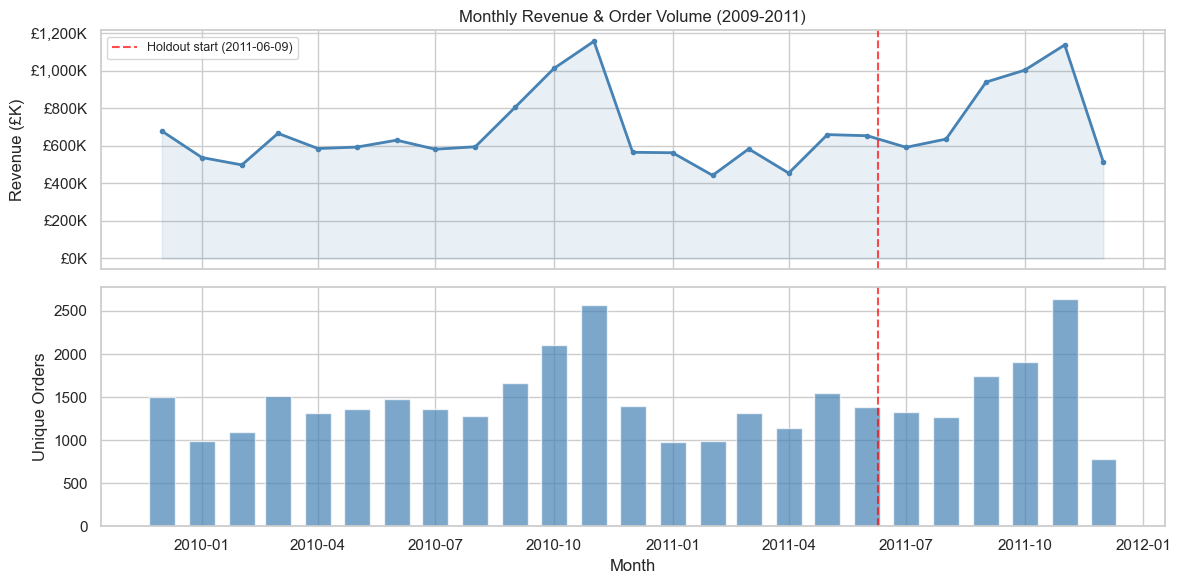

Top 3 revenue months:
  2010-11  £1,155,978  (2,570 orders)
  2011-11  £1,136,534  (2,642 orders)
  2010-10  £1,011,557  (2,108 orders)

2010 revenue: £8,223,006
2011 revenue: £8,172,028  (0.99x YoY growth)


In [11]:
# Monthly revenue and order volume (use full cleaned dataset, not just calibration)
df['month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('month').agg(
    revenue=('line_total', 'sum'),
    orders=('Invoice', 'nunique'),
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(monthly['month_dt'], monthly['revenue'] / 1e3,
         color='steelblue', linewidth=2, marker='o', markersize=3)
ax1.fill_between(monthly['month_dt'], monthly['revenue'] / 1e3, alpha=0.12, color='steelblue')
ax1.axvline(pd.Timestamp('2011-06-09'), color='red', linestyle='--', alpha=0.7,
            label='Holdout start (2011-06-09)')
ax1.set_ylabel('Revenue (£K)')
ax1.set_title('Monthly Revenue & Order Volume (2009-2011)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
ax1.legend(fontsize=9)

ax2.bar(monthly['month_dt'], monthly['orders'],
        color='steelblue', alpha=0.7, width=20)
ax2.axvline(pd.Timestamp('2011-06-09'), color='red', linestyle='--', alpha=0.7)
ax2.set_ylabel('Unique Orders')
ax2.set_xlabel('Month')

plt.tight_layout()
plt.show()

# Top revenue months
top3 = monthly.nlargest(3, 'revenue')[['month', 'revenue', 'orders']]
print("Top 3 revenue months:")
for _, row in top3.iterrows():
    print(f"  {row['month']}  £{row['revenue']:,.0f}  ({row['orders']:,} orders)")

# Year-over-year comparison (2010 vs 2011 only; Dec 2009 is the only 2009 data)
yr2010 = monthly[monthly['month_dt'].dt.year == 2010]['revenue'].sum()
yr2011 = monthly[monthly['month_dt'].dt.year == 2011]['revenue'].sum()
print(f"\n2010 revenue: £{yr2010:,.0f}")
print(f"2011 revenue: £{yr2011:,.0f}  ({yr2011/yr2010:.2f}x YoY growth)")

**Observations:**
- **Q4 seasonality is clear.** November is the peak revenue month in both 2010 and 2011 (visible in chart), consistent with UK holiday gifting behaviour.
- **YoY comparison is approximate.** The dataset ends December 9, 2011, so most of December 2011 is missing. Given that November-December is peak season, the apparent decline from 2010 to 2011 is likely an artifact of incomplete data rather than a real revenue drop.
- **Order volume and revenue track closely**, suggesting average order values are stable over time.
- The red dashed line marks the holdout window start. The model is trained on everything to the left.

### 6.2 Customer Behavior (RFM Analysis)

Examine the distributions of recency, frequency, and monetary value, the three pillars of customer-level behavioral modeling. We also check whether one-time buyers repurchase in the holdout window, which determines whether they should be included in the model.

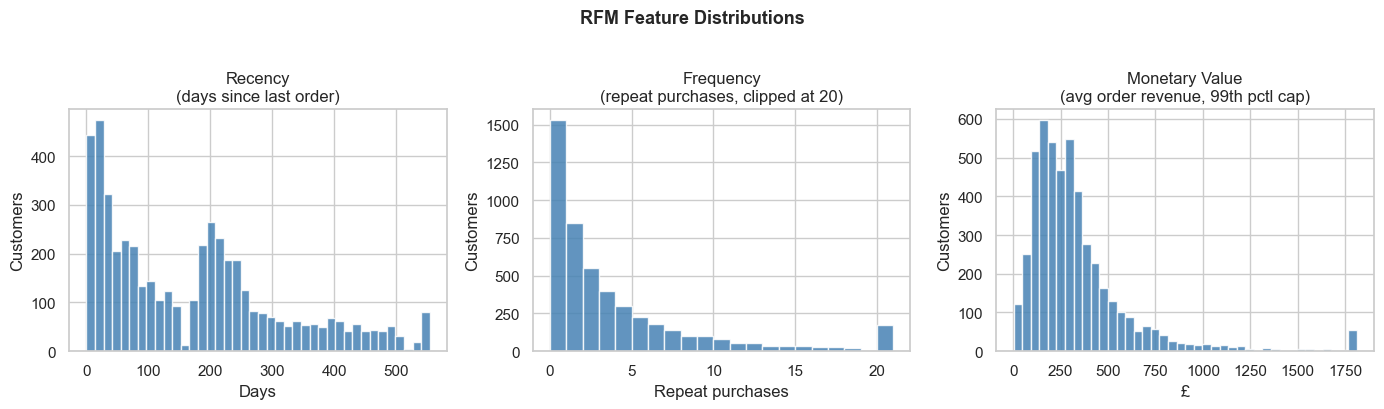

One-time buyers (frequency=0): 31.1% (1,528 customers)
Median recency:                149 days
Median monetary value:         £269


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Recency
axes[0].hist(customers['recency'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Recency\n(days since last order)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Customers')

# Frequency (clipped at 20 for readability)
axes[1].hist(customers['frequency'].clip(upper=20), bins=range(22),
             color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Frequency\n(repeat purchases, clipped at 20)')
axes[1].set_xlabel('Repeat purchases')
axes[1].set_ylabel('Customers')

# Monetary value (capped at 99th percentile)
mv_cap = customers['monetary_value'].quantile(0.99)
axes[2].hist(customers['monetary_value'].clip(upper=mv_cap), bins=40,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[2].set_title(f'Monetary Value\n(avg order revenue, 99th pctl cap)')
axes[2].set_xlabel('£')
axes[2].set_ylabel('Customers')

plt.suptitle('RFM Feature Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"One-time buyers (frequency=0): {(customers['frequency']==0).mean():.1%} ({(customers['frequency']==0).sum():,} customers)")
print(f"Median recency:                {customers['recency'].median():.0f} days")
print(f"Median monetary value:         £{customers['monetary_value'].median():,.0f}")

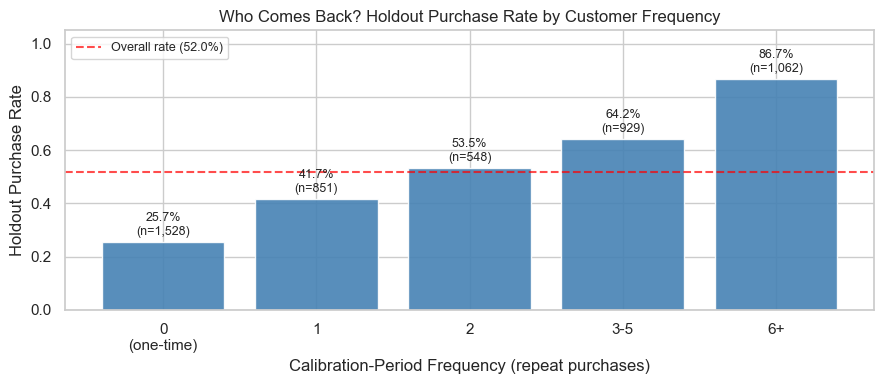

Holdout purchase rate by frequency bucket:
  freq=0 (one-time)  25.7%  (n=1,528)
  freq=1             41.7%  (n=851)
  freq=2             53.5%  (n=548)
  freq=3-5           64.2%  (n=929)
  freq=6+            86.7%  (n=1,062)


In [13]:
# Holdout purchase rate by calibration-period frequency bucket
def freq_bucket(f):
    if f == 0:    return '0\n(one-time)'
    elif f == 1:  return '1'
    elif f == 2:  return '2'
    elif f <= 5:  return '3-5'
    else:         return '6+'

_freq_buckets = customers['frequency'].apply(freq_bucket)
bucket_order = ['0\n(one-time)', '1', '2', '3-5', '6+']
holdout_rate  = customers.groupby(_freq_buckets)['purchased_in_holdout'].mean().reindex(bucket_order)
bucket_counts = customers.groupby(_freq_buckets).size().reindex(bucket_order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(holdout_rate.index, holdout_rate.values,
              color='steelblue', edgecolor='white', alpha=0.9)
ax.axhline(customers['purchased_in_holdout'].mean(), color='red', linestyle='--',
           alpha=0.7, label=f'Overall rate ({customers["purchased_in_holdout"].mean():.1%})')

for bar, val, n in zip(bars, holdout_rate.values, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f'{val:.1%}\n(n={n:,})',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Calibration-Period Frequency (repeat purchases)')
ax.set_ylabel('Holdout Purchase Rate')
ax.set_title('Who Comes Back? Holdout Purchase Rate by Customer Frequency')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("Holdout purchase rate by frequency bucket:")
for bucket, rate, n in zip(bucket_order, holdout_rate.values, bucket_counts.values):
    label = bucket.replace('\n', ' ')
    print(f"  freq={label:<12}  {rate:.1%}  (n={n:,})")

**Observations:**
- **One-time buyers still repurchase** (see printed rates above). Excluding them would bias the model and underestimate churn risk. Binary classification is the right approach.
- **Frequency is the strongest behavioral signal:** customers with 6+ historical orders repurchase at 3-4x the rate of one-time buyers
- **Monetary value is right-skewed.** A small number of high-value customers (likely B2B/wholesale) pull the mean above the median (£269), motivating tier-based revenue estimation rather than individual regression.
- **`recency`** follows the standard RFM definition: days since the customer's last order before the calibration cutoff. Lower values indicate more recently active customers.

### 6.3 Revenue Concentration

Quantify how much revenue is driven by the top customers using a Lorenz curve. High concentration justifies a tier-based segmentation strategy where marketing spend is allocated proportionally to customer value.

Revenue concentration (historical calibration spend):
  Top 10% of customers → 61.8% of total revenue
  Top 20% of customers → 75.5% of total revenue
  Top 50% of customers → 92.9% of total revenue


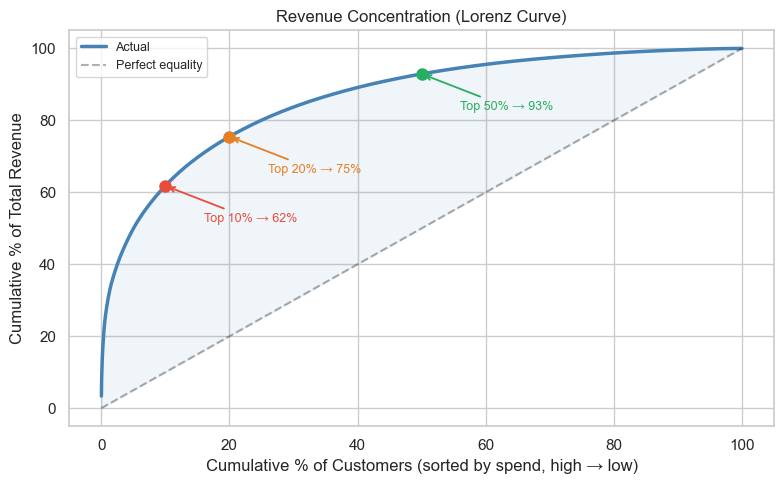

In [14]:
# Lorenz-style cumulative revenue curve
sorted_customers = customers.sort_values('total_spend', ascending=False).reset_index(drop=True)
sorted_customers['cum_pct_customers'] = (sorted_customers.index + 1) / len(sorted_customers)
sorted_customers['cum_pct_revenue']   = sorted_customers['total_spend'].cumsum() / sorted_customers['total_spend'].sum()

# Stats at key thresholds
thresholds = [0.10, 0.20, 0.50]
print("Revenue concentration (historical calibration spend):")
for t in thresholds:
    idx = int(t * len(sorted_customers)) - 1
    rev_pct = sorted_customers.loc[idx, 'cum_pct_revenue']
    print(f"  Top {t:.0%} of customers → {rev_pct:.1%} of total revenue")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_customers['cum_pct_customers'] * 100,
        sorted_customers['cum_pct_revenue'] * 100,
        color='steelblue', linewidth=2.5, label='Actual')
ax.plot([0, 100], [0, 100], 'k--', alpha=0.35, label='Perfect equality')
ax.fill_between(sorted_customers['cum_pct_customers'] * 100,
                sorted_customers['cum_pct_revenue'] * 100,
                sorted_customers['cum_pct_customers'] * 100,
                alpha=0.08, color='steelblue')

colors = ['#e74c3c', '#e67e22', '#27ae60']
for t, color in zip(thresholds, colors):
    idx = int(t * len(sorted_customers)) - 1
    rev_pct = sorted_customers.loc[idx, 'cum_pct_revenue']
    ax.annotate(f'Top {t:.0%} → {rev_pct:.0%}',
                xy=(t * 100, rev_pct * 100),
                xytext=(t * 100 + 6, rev_pct * 100 - 10),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.3))
    ax.plot(t * 100, rev_pct * 100, 'o', color=color, markersize=8, zorder=5)

ax.set_xlabel('Cumulative % of Customers (sorted by spend, high → low)')
ax.set_ylabel('Cumulative % of Total Revenue')
ax.set_title('Revenue Concentration (Lorenz Curve)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** Revenue is highly concentrated:
- Top **10%** of customers → **61.8%** of total calibration revenue
- Top **20%** of customers → **75.5%** of total calibration revenue
- Top **50%** of customers → **92.9%** of total calibration revenue

This validates the 4-tier segmentation approach in `03_customer_lifetime_value_segmentation.ipynb`: protecting and growing the top tier yields outsized returns relative to the resources spent.

### 6.4 Geographic Distribution

Check the geographic mix and whether country correlates with spend levels. Since this is a UK-based retailer, we expect heavy domestic concentration, which has implications for model generalizability.

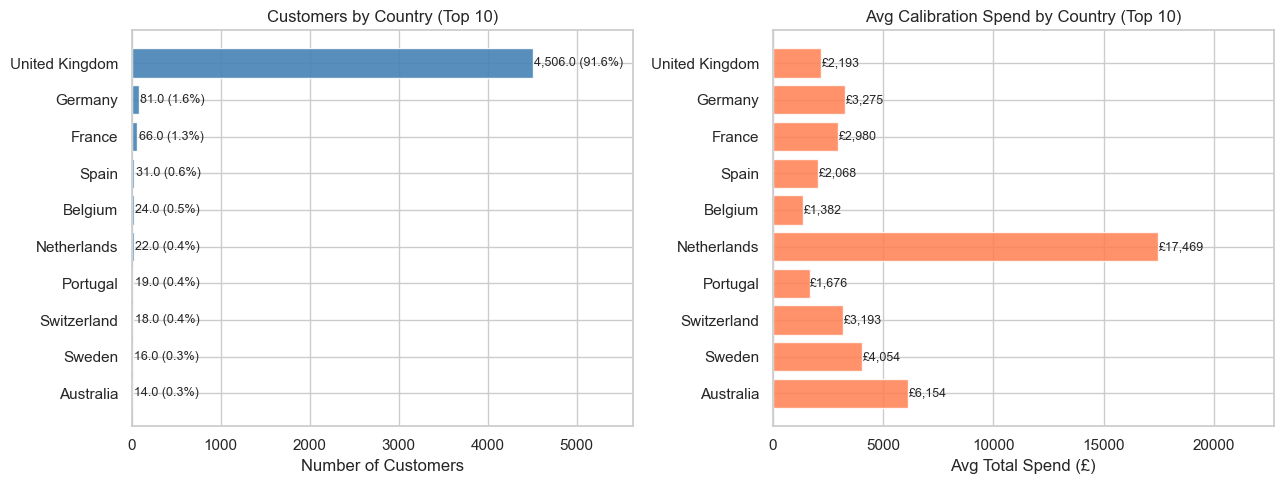

UK share: 4,506 customers (91.6%)
Avg spend, UK: £2,193 | Non-UK: £4,546


In [15]:
country_stats = (customers.groupby('country')
                .agg(n_customers=('user_id', 'count'),
                     avg_spend=('total_spend', 'mean'))
                .sort_values('n_customers', ascending=False)
                .head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Customers by country
axes[0].barh(country_stats.index[::-1], country_stats['n_customers'][::-1],
             color='steelblue', edgecolor='white', alpha=0.9)
for i, (idx, row) in enumerate(country_stats[::-1].iterrows()):
    n, pct = row['n_customers'], row['n_customers'] / len(customers)
    axes[0].text(n + 15, i, f'{n:,} ({pct:.1%})', va='center', fontsize=9)
axes[0].set_title('Customers by Country (Top 10)')
axes[0].set_xlabel('Number of Customers')
axes[0].set_xlim(0, country_stats['n_customers'].max() * 1.25)

# Avg spend by country
axes[1].barh(country_stats.index[::-1], country_stats['avg_spend'][::-1],
             color='coral', edgecolor='white', alpha=0.85)
for i, (idx, row) in enumerate(country_stats[::-1].iterrows()):
    axes[1].text(row['avg_spend'] + 30, i, f'£{row["avg_spend"]:,.0f}', va='center', fontsize=9)
axes[1].set_title('Avg Calibration Spend by Country (Top 10)')
axes[1].set_xlabel('Avg Total Spend (£)')
axes[1].set_xlim(0, country_stats['avg_spend'].max() * 1.3)

plt.tight_layout()
plt.show()

uk_n = (customers['country'] == 'United Kingdom').sum()
print(f"UK share: {uk_n:,} customers ({uk_n/len(customers):.1%})")
non_uk = customers[customers['country'] != 'United Kingdom']
uk     = customers[customers['country'] == 'United Kingdom']
print(f"Avg spend, UK: £{uk['total_spend'].mean():,.0f} | Non-UK: £{non_uk['total_spend'].mean():,.0f}")

**Observations:**
- **91.6% of customers are UK-based.** The model is predominantly UK-calibrated and may not generalize well to other markets.
- **Non-UK customers tend to spend more on average**, likely B2B/wholesale accounts, which inflates international revenue figures.
- Country is included as a model feature, but with limited geographic diversity it has low predictive power beyond the UK/international split.

### 6.5 Feature Correlations

Examine pairwise correlations between engineered features and the holdout purchase target. This helps confirm which features carry the most predictive signal before model training.

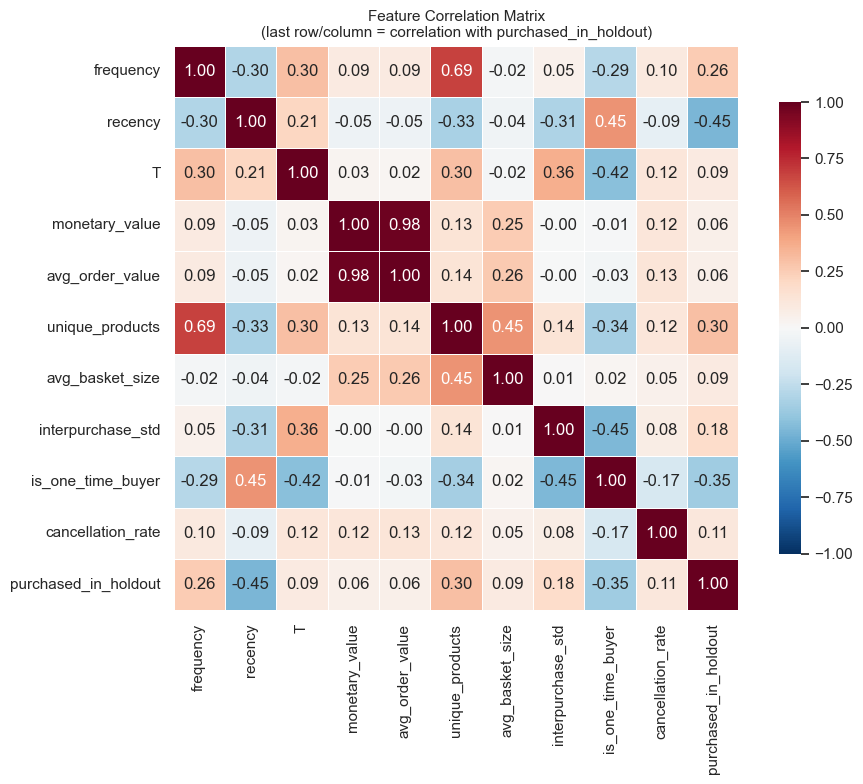

All feature correlations with purchased_in_holdout (sorted):
  recency                        -0.453
  is_one_time_buyer              -0.354
  unique_products                +0.304
  frequency                      +0.255
  interpurchase_std              +0.182
  cancellation_rate              +0.112
  T                              +0.091
  avg_basket_size                +0.088
  avg_order_value                +0.056
  monetary_value                 +0.055


In [16]:
numeric_features = [
    'frequency', 'recency', 'T', 'monetary_value', 'avg_order_value',
    'unique_products', 'avg_basket_size',
    'interpurchase_std', 'is_one_time_buyer', 'cancellation_rate', 'purchased_in_holdout',
]
corr = customers[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
    ax=ax, vmin=-1, vmax=1,
)
ax.set_title('Feature Correlation Matrix\n(last row/column = correlation with purchased_in_holdout)',
             fontsize=11)
plt.tight_layout()
plt.show()

print("All feature correlations with purchased_in_holdout (sorted):")
target_corr = corr['purchased_in_holdout'].drop('purchased_in_holdout').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    print(f"  {feat:<30} {val:+.3f}")

**Observations:**
- **`recency`** is the strongest single predictor (r = −0.45). Customers who bought recently are far more likely to repurchase. This is the classic RFM recency signal.
- **`is_one_time_buyer`** (r = −0.35) and **`unique_products`** (r = +0.30) are the next strongest. Product breadth is a meaningful engagement signal beyond just order count.
- **`monetary_value` and `avg_order_value` are near-perfectly correlated (r = 0.98).** Both capture spending magnitude with almost no independent information. Tree-based models handle this gracefully (they'll select one per split), but it explains why neither individually ranks high against the target (r ≈ +0.06).
- **`frequency` and `unique_products` (r = 0.69)** share substantial signal. Frequent buyers naturally accumulate more distinct products. Similarly, **`recency` and `is_one_time_buyer`** (r = 0.45) overlap because one-time buyers tend to have older last-purchase dates.
- **Spending features are weak predictors.** `monetary_value`, `avg_order_value`, and `avg_basket_size` all correlate below +0.10 with the target. Behavioral signals (when and how often) dominate over how much.


## 7. Key Takeaways & Modeling Rationale

The EDA findings directly inform the two-stage modeling approach used in the next notebooks:

| Finding | Modeling implication |
|---------|---------------------|
| 31% one-time buyers still repurchase | Binary classification first (Stage 1). Don't exclude them. |
| `recency` is the top predictor (r = −0.45) | RFM features are the right feature set for Stage 1 |
| 52% holdout positive rate (near-balanced classes) | No heavy class weighting needed; standard binary cross-entropy works |
| Revenue is highly concentrated (top 20% → 75.5%) | Tier-based segmentation (Stage 2) captures most of the value efficiently |
| Revenue is right-skewed with high variance | Spend tiers are more robust than individual-level regression for revenue estimation |
| `monetary_value` ↔ `avg_order_value` (r = 0.98) | Near-redundant features. Tree models self-select, but worth monitoring in SHAP interpretation. |

**Next:** `02_purchase_propensity_model.ipynb`, a 4-model comparison (Logistic Regression, Random Forest, XGBoost, LightGBM) with Optuna-tuned XGBoost as the final calibrated classifier.

## 8. Save Output


In [17]:
# Save customer-level CLV data for notebook 02 (stage 1 modeling)
os.makedirs('../data/processed', exist_ok=True)
customers.to_csv('../data/processed/clv_data.csv', index=False)
print(f"Saved: data/processed/clv_data.csv")

Saved: data/processed/clv_data.csv



---

## Appendix

<details>
<summary><b>Data Dictionary: <code>clv_data.csv</code></b></summary>

<!-- ## Data Dictionary: `clv_data.csv` -->

### Features (inputs to the model)

| Column | Type | Description |
|---|---|---|
| `user_id` | int | Customer identifier |
| `frequency` | int | Number of repeat purchases (total_orders - 1) |
| `recency` | int | Days from last order to calibration end (2011-06-09), standard RFM recency |
| `T` | int | Customer age in days at calibration end (2011-06-09) |
| `monetary_value` | float | Avg order revenue on repeat transactions; falls back to avg_order_value for one-time buyers |
| `total_orders` | int | Total distinct invoices in calibration period |
| `total_spend` | float | Total calibration spend |
| `avg_order_value` | float | Mean order revenue across all calibration orders |
| `unique_products` | int | Distinct StockCodes purchased across calibration |
| `avg_basket_size` | float | Mean distinct products per order |
| `interpurchase_std` | float | Std dev of inter-purchase intervals in days; **0 = one-time buyer** (insufficient history) |
| `is_one_time_buyer` | int | Binary flag: 1 if customer made only one purchase in calibration period |
| `cancellation_rate` | float | Fraction of orders that were cancellations (computed from calibration period only) |
| `country` | str | Customer's most frequent country of purchase |

### Holdout labels (validation targets, not model inputs)

| Column | Type | Description |
|---|---|---|
| `actual_holdout_transactions` | int | Distinct invoices in holdout window (2011-06-09 to 2011-12-09) |
| `actual_holdout_revenue` | float | Total revenue in holdout window |
| `purchased_in_holdout` | int | Binary target: 1 if customer made ≥1 holdout purchase |

</details>